Step 1 — Check the file

In [28]:
!ls

pawiki-latest-pages-articles.xml.bz2  sample_data
punjabi_gurmukhi_corpus_cleaned.txt   urdu_corpus_cleaned.txt
punjabi_gurmukhi_corpus.txt	      urdu_corpus_normalized.txt
punjabi_shahmukhi_corpus_final.txt    urdu_corpus.txt
punjabi_shahmukhi_corpus.txt	      urwiki-latest-pages-articles.xml.bz2


Step 2 — Install required libraries

In [29]:
!pip install mwparserfromhell lxml

In [30]:
!rm -f urwiki-latest-pages-articles.xml.bz2
!wget -O urwiki-latest-pages-articles.xml.bz2 https://dumps.wikimedia.org/urwiki/latest/urwiki-latest-pages-articles.xml.bz2

--2026-03-16 15:23:38--  https://dumps.wikimedia.org/urwiki/latest/urwiki-latest-pages-articles.xml.bz2
Resolving dumps.wikimedia.org (dumps.wikimedia.org)... 208.80.154.71, 2620:0:861:3:208:80:154:71
Connecting to dumps.wikimedia.org (dumps.wikimedia.org)|208.80.154.71|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 344748287 (329M) [application/octet-stream]
Saving to: ‘urwiki-latest-pages-articles.xml.bz2’

urwiki-latest-pages 100%[===================>] 328.78M  3.11MB/s    in 1m 51s  

2026-03-16 15:25:29 (2.97 MB/s) - ‘urwiki-latest-pages-articles.xml.bz2’ saved [344748287/344748287]



Extract plain Urdu text from the Wikipedia dump

In [31]:
import bz2
import xml.etree.ElementTree as ET
import mwparserfromhell
import re

input_file = "urwiki-latest-pages-articles.xml.bz2"
output_file = "urdu_corpus.txt"

BAD_TITLE_PREFIXES = (
    "ویکیپیڈیا:", "زمرہ:", "سانچہ:", "صارف:", "معاونت:",
    "ملف:", "تبادلۂ خیال:", "پورٹل:", "موضوع:"
)

def clean_text(text):
    if not text:
        return ""
    code = mwparserfromhell.parse(text)
    plain = code.strip_code()
    plain = re.sub(r"\s+", " ", plain).strip()
    return plain

count = 0
saved = 0

with bz2.open(input_file, "rb") as f, open(output_file, "w", encoding="utf-8") as out:
    context = ET.iterparse(f, events=("end",))
    current_title = None

    for event, elem in context:
        tag = elem.tag.split("}")[-1]

        if tag == "title":
            current_title = elem.text or ""

        elif tag == "page":
            if current_title and current_title.startswith(BAD_TITLE_PREFIXES):
                elem.clear()
                continue

            text_content = None
            for child in elem.iter():
                child_tag = child.tag.split("}")[-1]
                if child_tag == "text":
                    text_content = child.text
                    break

            cleaned = clean_text(text_content)
            if cleaned and len(cleaned.split()) >= 5:
                out.write(cleaned + "\n")
                saved += 1

            count += 1
            if count % 10000 == 0:
                print(f"Processed {count} pages | Saved {saved} lines")

            elem.clear()

print("Done. Saved to", output_file)
print("Total processed pages:", count)
print("Total saved lines:", saved)

Processed 10000 pages | Saved 5562 lines
Processed 20000 pages | Saved 10932 lines
Processed 30000 pages | Saved 17628 lines
Processed 40000 pages | Saved 24603 lines
Processed 50000 pages | Saved 32833 lines
Processed 60000 pages | Saved 37591 lines
Processed 70000 pages | Saved 38835 lines
Processed 80000 pages | Saved 40983 lines
Processed 90000 pages | Saved 48577 lines
Processed 100000 pages | Saved 57055 lines
Processed 110000 pages | Saved 58487 lines
Processed 120000 pages | Saved 59885 lines
Processed 130000 pages | Saved 62327 lines
Processed 140000 pages | Saved 70286 lines
Processed 150000 pages | Saved 73049 lines
Processed 160000 pages | Saved 80753 lines
Processed 170000 pages | Saved 82830 lines
Processed 180000 pages | Saved 86638 lines
Processed 190000 pages | Saved 91122 lines
Processed 200000 pages | Saved 96410 lines
Processed 210000 pages | Saved 101286 lines
Processed 220000 pages | Saved 107472 lines
Processed 230000 pages | Saved 116716 lines
Processed 240000 p

1. Check the first lines of the corpus

In [32]:
!head -n 20 urdu_corpus.txt

اس صفحےکو غیر محفوظ کریں
یہ صفحہ آخری دفعہ $1 کو ترمیم کیا گیا۔
آپ کے لیے $1 آیا ہے۔
بہ تاسف! ویکی کو چند طرزیاتی (ٹکنیکی) مشکلات کا سامنا ہے، اساسی موادی کمک کنندہ ( ڈیٹا بیس سرور ) سے تک پہنچنے میں ناکامی ہوئی۔ $1
اردو ویکیپیڈیا میں تصویر:Khushamdeedmsg.PNG! Welcome to Urdu Wikipedia السلام علیکم! ہم امید کرتے ہیں کہ آپ اُردو ویکیپیڈیا کے لیے بہترین اضافہ ثابت ہوں گے۔ اگر آپ کھاتا بنا چکے ہیں (یا بناتے ہیں) تو آپ کا ایک مخصوص صفحۂ صارف بھی ہوگا جہاں آپ اپنا تعارف لکھ سکتے ہیں۔ آپ جب داخل ہوں گے تو اپنے تبادلۂ خیال صفحہ پر دیگر ساتھیوں سے پیغامات وصول کرسکتے ہیں۔ پیغام کے آخر میں اپنی دستخط ضرور کیجیئے؛ اس کے لیے درج کیجیے یہ علامت --~~~~ یا اس (link=) نشان پر طق کیجیے۔ تعارفی صفحات، آپ اور دائرۃ المعارف<li> صفحۂ تعارف <li> آسان راہنما<li> پڑھنا لکھنا دشوار؟ <li> معلومات برائے نئے صارفین<li> Urdu Support <li> کمپیوٹر پر اردوصفحات برائے تحریر و تدوین نیا مضمون شروع کرنے کے بارے میں ہدایات معلومات برائے نئے صارفین پر دیکھیئے۔ ویکیپیڈیا پر مقالات کی ہم آہنگی اور بہتر تدوین کی خاطر ایک صف

2. Count the total tokens and vocabulary

In [33]:
tokens = 0
vocab = set()

with open("urdu_corpus.txt", "r", encoding="utf-8") as f:
    for line in f:
        words = line.split()
        tokens += len(words)
        vocab.update(words)

print("Raw Urdu Tokens:", tokens)
print("Raw Urdu Vocabulary:", len(vocab))

Raw Urdu Tokens: 70545064
Raw Urdu Vocabulary: 2668591


Count the number of lines

In [34]:
!wc -l urdu_corpus.txt

711158 urdu_corpus.txt


The raw Urdu corpus extracted from Wikipedia contains a large vocabulary because it still includes noise such as punctuation-attached tokens, administrative page content, spelling variants, and formatting artifacts. Therefore, additional cleaning and normalization are required before training embeddings.

Step 3 — Clean the Urdu corpus

In [35]:
import re

input_file = "urdu_corpus.txt"
output_file = "urdu_corpus_cleaned.txt"

NOISE_PATTERNS = [
    r"\bزمرہ\b", r"\bرجوع\b", r"\bمکرر\b",
    r"\bویکیپیڈیا\b", r"\bسانچہ\b", r"\bصارف\b",
    r"\bصفحہ\b", r"\bمحفوظ\b", r"\bترمیم\b",
    r"\bمعاونت\b", r"\bپورٹل\b", r"\bمنصوبہ\b",
    r"\bدیگر زبانیں\b", r"\bآخری دفعہ\b",
    r"\bتصویر\b", r"\bتبادلۂ خیال\b", r"\bکھاتا\b"
]

def clean_urdu_text(text):
    text = text.replace("\u200c", " ")
    text = text.replace("\ufeff", " ")
    text = text.replace("$1", " ")
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^\u0600-\u06FF\s]", " ", text)

    for pattern in NOISE_PATTERNS:
        text = re.sub(pattern, " ", text)

    text = re.sub(r"\s+", " ", text).strip()
    return text

with open(input_file, "r", encoding="utf-8") as infile, open(output_file, "w", encoding="utf-8") as outfile:
    for line in infile:
        cleaned = clean_urdu_text(line)
        if cleaned and len(cleaned.split()) >= 5:
            outfile.write(cleaned + "\n")

print("Done. Cleaned corpus saved to", output_file)

Done. Cleaned corpus saved to urdu_corpus_cleaned.txt


In [36]:
tokens = 0
vocab = set()

with open("urdu_corpus_cleaned.txt", "r", encoding="utf-8") as f:
    for line in f:
        words = line.split()
        tokens += len(words)
        vocab.update(words)

print("Cleaned Urdu Tokens:", tokens)
print("Cleaned Urdu Vocabulary:", len(vocab))

Cleaned Urdu Tokens: 62178964
Cleaned Urdu Vocabulary: 853920


In [37]:
!wc -l urdu_corpus_cleaned.txt

555465 urdu_corpus_cleaned.txt


In [38]:
input_file = "urdu_corpus_cleaned.txt"
output_file = "urdu_corpus_normalized.txt"

def normalize_urdu(text):
    text = text.replace("ي", "ی")
    text = text.replace("ك", "ک")
    text = text.replace("ھ", "ہ")
    text = text.replace("ة", "ہ")
    text = text.replace("ۀ", "ہ")
    return text

with open(input_file, "r", encoding="utf-8") as infile, open(output_file, "w", encoding="utf-8") as outfile:
    for line in infile:
        normalized = normalize_urdu(line)
        if normalized.strip():
            outfile.write(normalized)

print("Normalization complete.")

Normalization complete.


In [39]:
tokens = 0
vocab = set()

with open("urdu_corpus_normalized.txt", "r", encoding="utf-8") as f:
    for line in f:
        words = line.split()
        tokens += len(words)
        vocab.update(words)

print("Final Urdu Tokens:", tokens)
print("Final Urdu Vocabulary:", len(vocab))

Final Urdu Tokens: 62178964
Final Urdu Vocabulary: 827662


In [40]:
!head -n 20 urdu_corpus_cleaned.txt

آپ کے لیے آیا ہے۔
بہ تاسف ویکی کو چند طرزیاتی ٹکنیکی مشکلات کا سامنا ہے، اساسی موادی کمک کنندہ ڈیٹا بیس سرور سے تک پہنچنے میں ناکامی ہوئی۔
اردو میں السلام علیکم ہم امید کرتے ہیں کہ آپ اُردو کے لیے بہترین اضافہ ثابت ہوں گے۔ اگر آپ بنا چکے ہیں یا بناتے ہیں تو آپ کا ایک مخصوص صفحۂ بھی ہوگا جہاں آپ اپنا تعارف لکھ سکتے ہیں۔ آپ جب داخل ہوں گے تو اپنے پر دیگر ساتھیوں سے پیغامات وصول کرسکتے ہیں۔ پیغام کے آخر میں اپنی دستخط ضرور کیجیئے؛ اس کے لیے درج کیجیے یہ علامت یا اس نشان پر طق کیجیے۔ تعارفی صفحات، آپ اور دائرۃ المعارف صفحۂ تعارف آسان راہنما پڑھنا لکھنا دشوار؟ معلومات برائے نئے صارفین کمپیوٹر پر اردوصفحات برائے تحریر و تدوین نیا مضمون شروع کرنے کے بارے میں ہدایات معلومات برائے نئے صارفین پر دیکھیئے۔ پر مقالات کی ہم آہنگی اور بہتر تدوین کی خاطر ایک بنام انداز مقالات ایک اور معاونتی ؛ ہدایات برائے تحریر۔ تحریر و ترامیم کرنے کے بارے میں ایک وضاحتی ؛ کیسے لکھیں؟۔
داخلے میں کوئی مسئلہ درپیش ہےدوبارہ اندراج کریں
، آپ پہلے ہی داخل حالت میں ہیں
کھاتہ بنائیں یا اندراج کریں
آپ نےجونام درج کیا ہے پہلے

The final Urdu corpus was produced through extraction, cleaning, and orthographic normalization. This preprocessing reduced vocabulary fragmentation and removed a substantial amount of noise, resulting in a more reliable corpus for embedding training.

**Punjabi section**

Step 4 — Download Punjabi Wikipedia dump

In [41]:
!rm -f pawiki-latest-pages-articles.xml.bz2
!wget -O pawiki-latest-pages-articles.xml.bz2 https://dumps.wikimedia.org/pawiki/latest/pawiki-latest-pages-articles.xml.bz2

--2026-03-16 15:58:07--  https://dumps.wikimedia.org/pawiki/latest/pawiki-latest-pages-articles.xml.bz2
Resolving dumps.wikimedia.org (dumps.wikimedia.org)... 208.80.154.71, 2620:0:861:3:208:80:154:71
Connecting to dumps.wikimedia.org (dumps.wikimedia.org)|208.80.154.71|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 94825464 (90M) [application/octet-stream]
Saving to: ‘pawiki-latest-pages-articles.xml.bz2’

pawiki-latest-pages 100%[===================>]  90.43M  3.32MB/s    in 27s     

2026-03-16 15:58:35 (3.32 MB/s) - ‘pawiki-latest-pages-articles.xml.bz2’ saved [94825464/94825464]



Step 5 — Extract Punjabi Wikipedia text

Extract Punjabi text from the dump

In [42]:
import bz2
import xml.etree.ElementTree as ET
import mwparserfromhell
import re

input_file = "pawiki-latest-pages-articles.xml.bz2"
output_file = "punjabi_gurmukhi_corpus.txt"

BAD_TITLE_PREFIXES = (
    "ਸ਼੍ਰੇਣੀ:", "ਵਿਕੀਪੀਡੀਆ:", "ਫਰਮਾ:", "ਵਰਤੋਂਕਾਰ:", "ਮਦਦ:",
    "ਤਸਵੀਰ:", "ਪੋਰਟਲ:", "ਮੀਡੀਆਵਿਕੀ:"
)

def clean_text(text):
    if not text:
        return ""
    code = mwparserfromhell.parse(text)
    plain = code.strip_code()
    plain = re.sub(r"\s+", " ", plain).strip()
    return plain

count = 0
saved = 0

with bz2.open(input_file, "rb") as f, open(output_file, "w", encoding="utf-8") as out:
    context = ET.iterparse(f, events=("end",))
    current_title = None

    for event, elem in context:
        tag = elem.tag.split("}")[-1]

        if tag == "title":
            current_title = elem.text or ""

        elif tag == "page":
            if current_title and current_title.startswith(BAD_TITLE_PREFIXES):
                elem.clear()
                continue

            text_content = None
            for child in elem.iter():
                child_tag = child.tag.split("}")[-1]
                if child_tag == "text":
                    text_content = child.text
                    break

            cleaned = clean_text(text_content)
            if cleaned and len(cleaned.split()) >= 5:
                out.write(cleaned + "\n")
                saved += 1

            count += 1
            if count % 10000 == 0:
                print(f"Processed {count} pages | Saved {saved} lines")

            elem.clear()

print("Done. Saved to", output_file)
print("Total processed pages:", count)
print("Total saved lines:", saved)

Processed 10000 pages | Saved 7026 lines
Processed 20000 pages | Saved 14730 lines
Processed 30000 pages | Saved 22013 lines
Processed 40000 pages | Saved 29464 lines
Processed 50000 pages | Saved 38036 lines
Processed 60000 pages | Saved 47119 lines
Processed 70000 pages | Saved 55439 lines
Done. Saved to punjabi_gurmukhi_corpus.txt
Total processed pages: 79229
Total saved lines: 63510


Step 6 — Clean Punjabi Gurmukhi corpus

In [43]:
import re

input_file = "punjabi_gurmukhi_corpus.txt"
output_file = "punjabi_gurmukhi_corpus_cleaned.txt"

def clean_punjabi_gurmukhi_text(text):
    text = text.replace("\u200c", " ")
    text = text.replace("\ufeff", " ")
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^\u0A00-\u0A7F\s]", " ", text)  # keep Gurmukhi only
    text = re.sub(r"\s+", " ", text).strip()
    return text

with open(input_file, "r", encoding="utf-8") as infile, open(output_file, "w", encoding="utf-8") as outfile:
    for line in infile:
        cleaned = clean_punjabi_gurmukhi_text(line)
        if cleaned and len(cleaned.split()) >= 3:
            outfile.write(cleaned + "\n")

print("Done. Cleaned Punjabi Gurmukhi corpus saved to", output_file)

Done. Cleaned Punjabi Gurmukhi corpus saved to punjabi_gurmukhi_corpus_cleaned.txt


Step 7 — Compute statistics for Punjabi Gurmukhi corpus

In [44]:
tokens = 0
vocab = set()

with open("punjabi_gurmukhi_corpus_cleaned.txt", "r", encoding="utf-8") as f:
    for line in f:
        words = line.split()
        tokens += len(words)
        vocab.update(words)

print("Punjabi Gurmukhi Tokens:", tokens)
print("Punjabi Gurmukhi Vocabulary:", len(vocab))

Punjabi Gurmukhi Tokens: 18576616
Punjabi Gurmukhi Vocabulary: 475156


In [45]:
!wc -l punjabi_gurmukhi_corpus_cleaned.txt

62124 punjabi_gurmukhi_corpus_cleaned.txt


Check Punjabi raw and cleaned output

In [46]:
!head -n 20 punjabi_gurmukhi_corpus_cleaned.txt

ਮੁੰਬਈ ਮੁੰਬਈ ਤੱਕ ਬੰਬਈ ਭਾਰਤ ਦੇ ਮਹਾਂਰਾਸ਼ਟਰ ਸੂਬੇ ਦੀ ਰਾਜਧਾਨੀ ਹੈ ਅਤੇ ਇਹ ਭਾਰਤ ਦਾ ਦੂਸਰਾ ਵੱਡਾ ਮਹਾਂਨਗਰ ਹੈ ਭਾਰਤ ਦੇ ਪੱਛਮੀ ਤੱਟ ਉੱਤੇ ਸਥਿਤ ਹੈ ਇਸ ਦੀ ਜਨਸੰਖਿਆ ਲਗਭਗ ਕਰੋੜ ਲੱਖ ਹੈ ਇਹ ਭਾਰਤ ਦਾ ਸਭ ਤੋਂ ਜਿਆਦਾ ਆਬਾਦੀ ਵਾਲਾ ਸ਼ਹਿਰ ਹੈ ਇਸ ਦਾ ਗਠਨ ਲਾਵਾ ਨਿਰਮਿਤ ਸੱਤ ਛੋਟੇ ਛੋਟੇ ਦੀਪਾਂ ਦੁਆਰਾ ਹੋਇਆ ਹੈ ਅਤੇ ਇਹ ਪੁਲਾਂ ਦੁਆਰਾ ਪ੍ਰਮੁੱਖ ਧਰਤੀ ਖੰਡ ਦੇ ਨਾਲ ਜੁੜਿਆ ਹੋਇਆ ਹੈ ਮੁੰਬਈ ਬੰਦਰਗਾਹ ਭਾਰਤ ਦਾ ਸਭ ਤੋਂ ਵੱਡੀ ਸਮੁੰਦਰੀ ਬੰਦਰਗਾਹ ਹੈ ਮੁੰਬਈ ਦਾ ਸਮੁੰਦਰੀ ਕਿਨਾਰਾ ਕਟਿਆ ਫੱਟਿਆ ਹੈ ਜਿਸਦੇ ਕਾਰਨ ਇਸ ਦਾ ਬੰਦਰਗਾਹ ਸੁਭਾਵਕ ਅਤੇ ਸੁਰੱਖਿਅਤ ਹੈ ਯੂਰਪ ਅਮਰੀਕਾ ਅਫਰੀਕਾ ਆਦਿ ਪੱਛਮੀ ਦੇਸ਼ਾਂ ਨਾਲ ਜਲਮਾਰਗ ਜਾਂ ਵਾਯੂ ਮਾਰਗ ਰਾਹੀਂ ਆਉਣ ਵਾਲੇ ਜਹਾਜ ਅਤੇ ਯਾਤਰੀ ਸਭ ਤੋਂ ਪਹਿਲਾਂ ਮੁੰਬਈ ਹੀ ਆਉਂਦੇ ਰਹੇ ਹਨ ਇਸ ਲਈ ਮੁੰਬਈ ਨੂੰ ਭਾਰਤ ਦਾ ਪ੍ਰਵੇਸ਼ਦਵਾਰ ਕਿਹਾ ਜਾਂਦਾ ਹੈ ਅੰਕੜੇ ਮੁੰਬਈ ਭਾਰਤ ਦਾ ਵੱਡਾ ਕਾਰੋਬਾਰੀ ਕੇਂਦਰ ਹੈ ਜਿਸਦੀ ਭਾਰਤ ਦੇ ਸਕਲ ਘਰੇਲੂ ਉਤਪਾਦ ਵਿੱਚ ਦੀ ਭਾਗੀਦਾਰੀ ਹੈ ਇਹ ਪੂਰੇ ਭਾਰਤ ਦੇ ਉਦਯੋਗਕ ਉਤਪਾਦ ਦਾ ਸਮੁੰਦਰੀ ਵਪਾਰ ਦਾ ਅਤੇ ਭਾਰਤੀ ਅਰਥ ਵਿਵਸਥਾ ਦੇ ਪੂੰਜੀ ਲੈਣ ਦੇਣ ਦਾ ਹਿੱਸੇਦਾਰ ਹੈ ਮੁੰਬਈ ਸੰਸਾਰ ਦੇ ਸਰਵ ਉੱਚ ਦਸ ਕਾਰੋਬਾਰੀ ਕੇਂਦਰਾਂ ਵਿੱਚੋਂ ਇੱਕ ਹੈ ਭਾਰਤ ਦੇ ਸਾਰੇ ਬੈਂਕ ਅਤੇ ਕਾਰੋਬਾਰੀ ਦਫਤਰਾਂ ਦੇ ਮੁੱਖ ਦਫਤਰ ਅਤੇ ਕਈ ਮਹੱਤਵਪੂਰਣ ਆਰਥਕ ਸੰਸਥਾਨ ਜਿਵੇਂ ਭਾਰਤੀ ਰਿਜਰਵ ਬੈਂਕ ਬੰਬਈ ਸਟਾਕ ਐਕਸਚੇ

In [47]:
!head -n 20 punjabi_gurmukhi_corpus.txt

thumb|ਮੁੰਬਈ, 1890 ਮੁੰਬਈ (1995 ਤੱਕ ਬੰਬਈ) ਭਾਰਤ ਦੇ ਮਹਾਂਰਾਸ਼ਟਰ ਸੂਬੇ ਦੀ ਰਾਜਧਾਨੀ ਹੈ ਅਤੇ ਇਹ ਭਾਰਤ ਦਾ ਦੂਸਰਾ ਵੱਡਾ ਮਹਾਂਨਗਰ ਹੈ। ਭਾਰਤ ਦੇ ਪੱਛਮੀ ਤੱਟ ਉੱਤੇ ਸਥਿਤ ਹੈ। ਇਸ ਦੀ ਜਨਸੰਖਿਆ ਲਗਭਗ 6 ਕਰੋੜ 60 ਲੱਖ ਹੈ। ਇਹ ਭਾਰਤ ਦਾ ਸਭ ਤੋਂ ਜਿਆਦਾ ਆਬਾਦੀ ਵਾਲਾ ਸ਼ਹਿਰ ਹੈ। ਇਸ ਦਾ ਗਠਨ ਲਾਵਾ ਨਿਰਮਿਤ ਸੱਤ ਛੋਟੇ-ਛੋਟੇ ਦੀਪਾਂ ਦੁਆਰਾ ਹੋਇਆ ਹੈ ਅਤੇ ਇਹ ਪੁਲਾਂ ਦੁਆਰਾ ਪ੍ਰਮੁੱਖ ਧਰਤੀ-ਖੰਡ ਦੇ ਨਾਲ ਜੁੜਿਆ ਹੋਇਆ ਹੈ। ਮੁੰਬਈ ਬੰਦਰਗਾਹ ਭਾਰਤ ਦਾ ਸਭ ਤੋਂ ਵੱਡੀ ਸਮੁੰਦਰੀ ਬੰਦਰਗਾਹ ਹੈ। ਮੁੰਬਈ ਦਾ ਸਮੁੰਦਰੀ ਕਿਨਾਰਾ ਕਟਿਆ-ਫੱਟਿਆ ਹੈ ਜਿਸਦੇ ਕਾਰਨ ਇਸ ਦਾ ਬੰਦਰਗਾਹ ਸੁਭਾਵਕ ਅਤੇ ਸੁਰੱਖਿਅਤ ਹੈ। ਯੂਰਪ, ਅਮਰੀਕਾ, ਅਫਰੀਕਾ ਆਦਿ ਪੱਛਮੀ ਦੇਸ਼ਾਂ ਨਾਲ ਜਲਮਾਰਗ ਜਾਂ ਵਾਯੂ ਮਾਰਗ ਰਾਹੀਂ ਆਉਣ ਵਾਲੇ ਜਹਾਜ ਅਤੇ ਯਾਤਰੀ ਸਭ ਤੋਂ ਪਹਿਲਾਂ ਮੁੰਬਈ ਹੀ ਆਉਂਦੇ ਰਹੇ ਹਨ ਇਸ ਲਈ ਮੁੰਬਈ ਨੂੰ ਭਾਰਤ ਦਾ ਪ੍ਰਵੇਸ਼ਦਵਾਰ ਕਿਹਾ ਜਾਂਦਾ ਹੈ। ਅੰਕੜੇ ਮੁੰਬਈ ਭਾਰਤ ਦਾ ਵੱਡਾ ਕਾਰੋਬਾਰੀ ਕੇਂਦਰ ਹੈ। ਜਿਸਦੀ ਭਾਰਤ ਦੇ ਸਕਲ ਘਰੇਲੂ ਉਤਪਾਦ ਵਿੱਚ 5 % ਦੀ ਭਾਗੀਦਾਰੀ ਹੈ। ਇਹ ਪੂਰੇ ਭਾਰਤ ਦੇ ਉਦਯੋਗਕ ਉਤਪਾਦ ਦਾ 25%,ਸਮੁੰਦਰੀ ਵਪਾਰ ਦਾ 40%, ਅਤੇ ਭਾਰਤੀ ਅਰਥ ਵਿਵਸਥਾ ਦੇ ਪੂੰਜੀ ਲੈਣ ਦੇਣ ਦਾ 70% ਹਿੱਸੇਦਾਰ ਹੈ। ਮੁੰਬਈ ਸੰਸਾਰ ਦੇ ਸਰਵ ਉੱਚ ਦਸ ਕਾਰੋਬਾਰੀ ਕੇਂਦਰਾਂ ਵਿੱਚੋਂ ਇੱਕ ਹੈ। ਭਾਰਤ ਦੇ ਸਾਰੇ ਬੈਂਕ ਅਤੇ ਕਾਰੋਬਾਰੀ ਦਫਤਰਾਂ ਦੇ ਮੁੱਖ ਦਫਤਰ ਅਤੇ ਕਈ ਮਹੱਤਵ

Transliterate Punjabi Gurmukhi to Shahmukhi

In [48]:
input_file = "punjabi_gurmukhi_corpus_cleaned.txt"
output_file = "punjabi_shahmukhi_corpus.txt"

mapping = {
    "ਅ":"ا","ਆ":"آ","ਇ":"ا","ਈ":"ی","ਉ":"ا","ਊ":"و","ਏ":"ے","ਐ":"ے","ਓ":"و","ਔ":"و",
    "ਕ":"ک","ਖ":"کھ","ਗ":"گ","ਘ":"گھ","ਙ":"نگ",
    "ਚ":"چ","ਛ":"چھ","ਜ":"ج","ਝ":"جھ","ਞ":"نج",
    "ਟ":"ٹ","ਠ":"ٹھ","ਡ":"ڈ","ਢ":"ڈھ","ਣ":"ن",
    "ਤ":"ت","ਥ":"تھ","ਦ":"د","ਧ":"دھ","ਨ":"ن",
    "ਪ":"پ","ਫ":"پھ","ਬ":"ب","ਭ":"بھ","ਮ":"م",
    "ਯ":"ی","ਰ":"ر","ਲ":"ل","ਵ":"و","ੜ":"ڑ",
    "ਸ":"س","ਹ":"ہ",
    "ਾ":"ا","ਿ":"ِ","ੀ":"ی","ੁ":"ُ","ੂ":"و","ੇ":"ے","ੈ":"ے","ੋ":"و","ੌ":"و",
    "ੰ":"ں","ਂ":"ں","ੱ":"", "੍":"", "਼":""
}

def transliterate(text):
    return "".join(mapping.get(ch, ch) for ch in text)

with open(input_file, "r", encoding="utf-8") as f, open(output_file, "w", encoding="utf-8") as out:
    for line in f:
        converted = transliterate(line.strip())
        if converted:
            out.write(converted + "\n")

print("Shahmukhi corpus created:", output_file)

Shahmukhi corpus created: punjabi_shahmukhi_corpus.txt


Clean the Shahmukhi corpus

In [49]:
import re

input_file = "punjabi_shahmukhi_corpus.txt"
output_file = "punjabi_shahmukhi_corpus_final.txt"

NOISE_WORDS = [
    "سرےنی", "ہوالے", "وکیپیڈیا", "پربندھک", "مکھ", "سپھا"
]

def clean_shahmukhi_text(text):
    text = text.replace("\u200c", " ")
    text = text.replace("\ufeff", " ")
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\d+", " ", text)

    # remove Arabic diacritics
    text = re.sub(r"[\u064B-\u065F]", "", text)

    # keep Arabic-script only
    text = re.sub(r"[^\u0600-\u06FF\s]", " ", text)

    for w in NOISE_WORDS:
        text = re.sub(rf"\b{re.escape(w)}\b", " ", text)

    text = re.sub(r"\s+", " ", text).strip()
    return text

with open(input_file, "r", encoding="utf-8") as infile, open(output_file, "w", encoding="utf-8") as outfile:
    for line in infile:
        cleaned = clean_shahmukhi_text(line)
        if cleaned and len(cleaned.split()) >= 5:
            outfile.write(cleaned + "\n")

print("Saved", output_file)

Saved punjabi_shahmukhi_corpus_final.txt


Shahmukhi statistics

In [50]:
from collections import Counter

freq = Counter()
lines = 0

with open("punjabi_shahmukhi_corpus.txt", "r", encoding="utf-8") as f:
    for line in f:
        words = line.split()
        freq.update(words)
        lines += 1

tokens = sum(freq.values())
vocab = len(freq)

print("Lines:", lines)
print("Tokens:", tokens)
print("Vocabulary:", vocab)

Lines: 62124
Tokens: 18576601
Vocabulary: 409774


In [51]:
!head -n 20 punjabi_shahmukhi_corpus_cleaned2.txt

head: cannot open 'punjabi_shahmukhi_corpus_cleaned2.txt' for reading: No such file or directory


Train Urdu Word2Vec

In [52]:
!pip install -q gensim mwparserfromhell lxml scikit-learn matplotlib

In [53]:
from gensim.models import Word2Vec
from gensim.models.word2vec import LineSentence

sentences = LineSentence("urdu_corpus_normalized.txt")

urdu_model = Word2Vec(
    sentences=sentences,
    vector_size=200,
    window=5,
    min_count=5,
    workers=4,
    sg=0
)

urdu_model.save("urdu_word2vec.model")
print("Saved urdu_word2vec.model")
print("Urdu vocabulary size:", len(urdu_model.wv))

Saved urdu_word2vec.model
Urdu vocabulary size: 158732


Train Punjabi Shahmukhi Word2Vec

In [54]:
from gensim.models import Word2Vec
from gensim.models.word2vec import LineSentence

sentences = LineSentence("punjabi_shahmukhi_corpus_final.txt")

punjabi_shahmukhi_model = Word2Vec(
    sentences=sentences,
    vector_size=200,
    window=5,
    min_count=2,
    workers=4,
    sg=0
)

punjabi_shahmukhi_model.save("punjabi_shahmukhi_word2vec_final.model")
print("Saved punjabi_shahmukhi_word2vec_final.model")
print("Punjabi Shahmukhi vocabulary size:", len(punjabi_shahmukhi_model.wv))

Saved punjabi_shahmukhi_word2vec_final.model
Punjabi Shahmukhi vocabulary size: 160589


Similarity evaluation

In [55]:
urdu_queries = ["پاکستان", "لاہور", "اردو", "پنجاب"]

for word in urdu_queries:
    if word in urdu_model.wv:
        print(f"\nUrdu nearest neighbors for: {word}")
        print(urdu_model.wv.most_similar(word, topn=10))
    else:
        print(f"{word} not found in Urdu vocabulary")


Urdu nearest neighbors for: پاکستان
[('پاکستانی', 0.6152732372283936), ('راولپنڈی', 0.608001708984375), ('بہارت', 0.6050609946250916), ('بلوچستان', 0.5889871716499329), ('لاہور', 0.5822409987449646), ('پشاور', 0.5735761523246765), ('سندہ', 0.5697363615036011), ('افغانستان', 0.5681344270706177), ('پنجاب', 0.5656516551971436), ('کراچی', 0.5639117360115051)]

Urdu nearest neighbors for: لاہور
[('راولپنڈی', 0.7685927748680115), ('کراچی', 0.75077885389328), ('پشاور', 0.7347201108932495), ('ملتان', 0.7292007207870483), ('سیالکوٹ', 0.6891413331031799), ('گوجرانوالہ', 0.6677089929580688), ('لاہور،', 0.6382414102554321), ('امرتسر', 0.6162248253822327), ('سرگودہا', 0.6145461201667786), ('کوئٹہ', 0.603877067565918)]

Urdu nearest neighbors for: اردو
[('اُردو', 0.7780063152313232), ('اردو،', 0.6562491059303284), ('سرائیکی', 0.6480771899223328), ('کہوار', 0.6453568339347839), ('گوجری', 0.6335433721542358), ('ادبیات', 0.6286054253578186), ('سندہی', 0.6210998296737671), ('ریختہ', 0.6114782094955444)

In [56]:
punjabi_queries = ["پاکستان", "لاہور", "پنجاب", "پنجابی"]

for word in punjabi_queries:
    if word in punjabi_shahmukhi_model.wv:
        print(f"\nPunjabi Shahmukhi nearest neighbors for: {word}")
        print(punjabi_shahmukhi_model.wv.most_similar(word, topn=10))
    else:
        print(f"{word} not found in Punjabi Shahmukhi vocabulary")


Punjabi Shahmukhi nearest neighbors for: پاکستان
[('بںگلادےس', 0.6915459632873535), ('اپھگانستان', 0.6848312020301819), ('کراچی', 0.6329449415206909), ('سںدھ', 0.6222321391105652), ('بلوچستان', 0.6107373833656311), ('پاکستانی', 0.5938603281974792), ('اسلاماباد', 0.5924046635627747), ('کھےبر', 0.5827896595001221), ('لاہور', 0.575924813747406), ('راولپںڈی', 0.5750489234924316)]

Punjabi Shahmukhi nearest neighbors for: لاہور
[('لہور', 0.7795929908752441), ('راولپںڈی', 0.7209509015083313), ('کراچی', 0.7196044921875), ('ملتان', 0.6752538084983826), ('گجراںوالا', 0.6624721884727478), ('پساور', 0.6527925729751587), ('اںمرتسر', 0.6480507254600525), ('اسلاماباد', 0.6308931708335876), ('سرگودھا', 0.6194714903831482), ('سآلکوٹ', 0.6166245341300964)]
پنجاب not found in Punjabi Shahmukhi vocabulary
پنجابی not found in Punjabi Shahmukhi vocabulary


Frequency analysis

For Urdu:

In [57]:
from collections import Counter

with open("urdu_corpus_normalized.txt", "r", encoding="utf-8") as f:
    words = f.read().split()

freq = Counter(words)
print(freq.most_common(20))

[('کے', 2556926), ('میں', 1962859), ('کی', 1808406), ('اور', 1258535), ('سے', 1031431), ('کا', 870125), ('نے', 696593), ('ء', 687362), ('اس', 603865), ('پر', 589296), ('ایک', 577737), ('ہے۔', 565852), ('کو', 565611), ('ہے', 460331), ('،', 344700), ('کرکٹ', 305865), ('جو', 289119), ('لیے', 282627), ('ان', 256246), ('وہ', 240764)]


In [60]:
from collections import Counter

freq = Counter()

with open("punjabi_shahmukhi_corpus.txt", "r", encoding="utf-8") as f:
    for line in f:
        freq.update(line.split())

for word, count in freq.most_common(50):
    print(word, count)

وِچ 637824
دے 548322
ہے 484971
اتے 468606
دی 381243
نوں 284088
دا 278352
اک 241425
سی 228286
اس 208401
اہ 196040
توں 195836
نے 169213
ہن 148933
لی 148428
نال 147681
تے 145060
سرےنی 120634
کیتا 108755
وی 98583
گِآ 95028
کِ 81094
کیتی 78937
جو 72871
جاںدا 61282
دیآں 60575
کرن 59375
اسنے 56803
بھارتی 56423
دُآرا 51787
ہوالے 50665
جِس 48207
بااد 48088
سِںگھ 48071
آپنے 47967
سن 47803
بھارت 47640
کے 47309
جنم 46767
گی 46765
جاں 45278
وجوں 43679
نہیں 40691
ہو 40541
تور 40045
ہواآ 39892
ہی 39516
لوک 38836
سال 37337
انہاں 37196


For Punjabi Shahmukhi:

In [63]:
tokens = 0
vocab = set()
lines = 0

with open("punjabi_shahmukhi_corpus_final.txt", "r", encoding="utf-8") as f:
    for line in f:
        words = line.split()
        tokens += len(words)
        vocab.update(words)
        lines += 1

print("Punjabi Shahmukhi Final Lines:", lines)
print("Punjabi Shahmukhi Final Tokens:", tokens)
print("Punjabi Shahmukhi Final Vocabulary:", len(vocab))

Punjabi Shahmukhi Final Lines: 61885
Punjabi Shahmukhi Final Tokens: 18384295
Punjabi Shahmukhi Final Vocabulary: 377630


In [64]:
from gensim.models import Word2Vec

punjabi_shahmukhi_model = Word2Vec.load("punjabi_shahmukhi_word2vec_final.model")
print("Loaded final Punjabi Shahmukhi model")
print("Vocabulary size:", len(punjabi_shahmukhi_model.wv))

Loaded final Punjabi Shahmukhi model
Vocabulary size: 160589


PCA visualization for Urdu

/tmp/ipykernel_240/1327183663.py:19: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.savefig("urdu_embedding_pca.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_240/1327183663.py:19: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.savefig("urdu_embedding_pca.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_240/1327183663.py:19: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.savefig("urdu_embedding_pca.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_240/1327183663.py:19: UserWarning: Glyph 1748 (\N{ARABIC FULL STOP}) missing from font(s) DejaVu Sans.
  plt.savefig("urdu_embedding_pca.png", dpi=300, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPyt

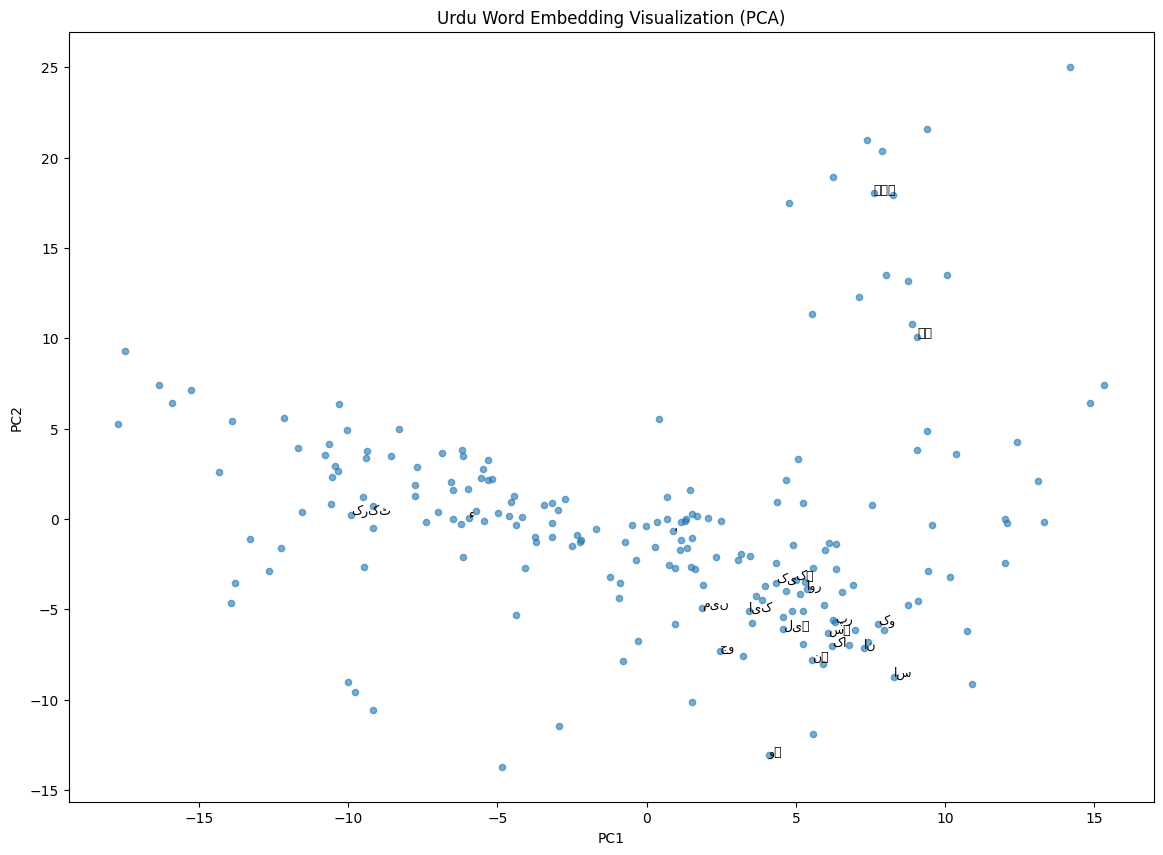

In [67]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

words = urdu_model.wv.index_to_key[:200]
vectors = urdu_model.wv[words]

pca = PCA(n_components=2)
result = pca.fit_transform(vectors)

plt.figure(figsize=(14, 10))
plt.scatter(result[:, 0], result[:, 1], alpha=0.6, s=20)

for i, word in enumerate(words[:20]):   # label only first 20
    plt.annotate(word, (result[i, 0], result[i, 1]), fontsize=9)

plt.title("Urdu Word Embedding Visualization (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.savefig("urdu_embedding_pca.png", dpi=300, bbox_inches="tight")
plt.show()

PCA visualization for Punjabi Shahmukhi

/tmp/ipykernel_240/378417730.py:19: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.savefig("punjabi_shahmukhi_embedding_pca.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_240/378417730.py:19: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.savefig("punjabi_shahmukhi_embedding_pca.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_240/378417730.py:19: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.savefig("punjabi_shahmukhi_embedding_pca.png", dpi=300, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Arabic natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib

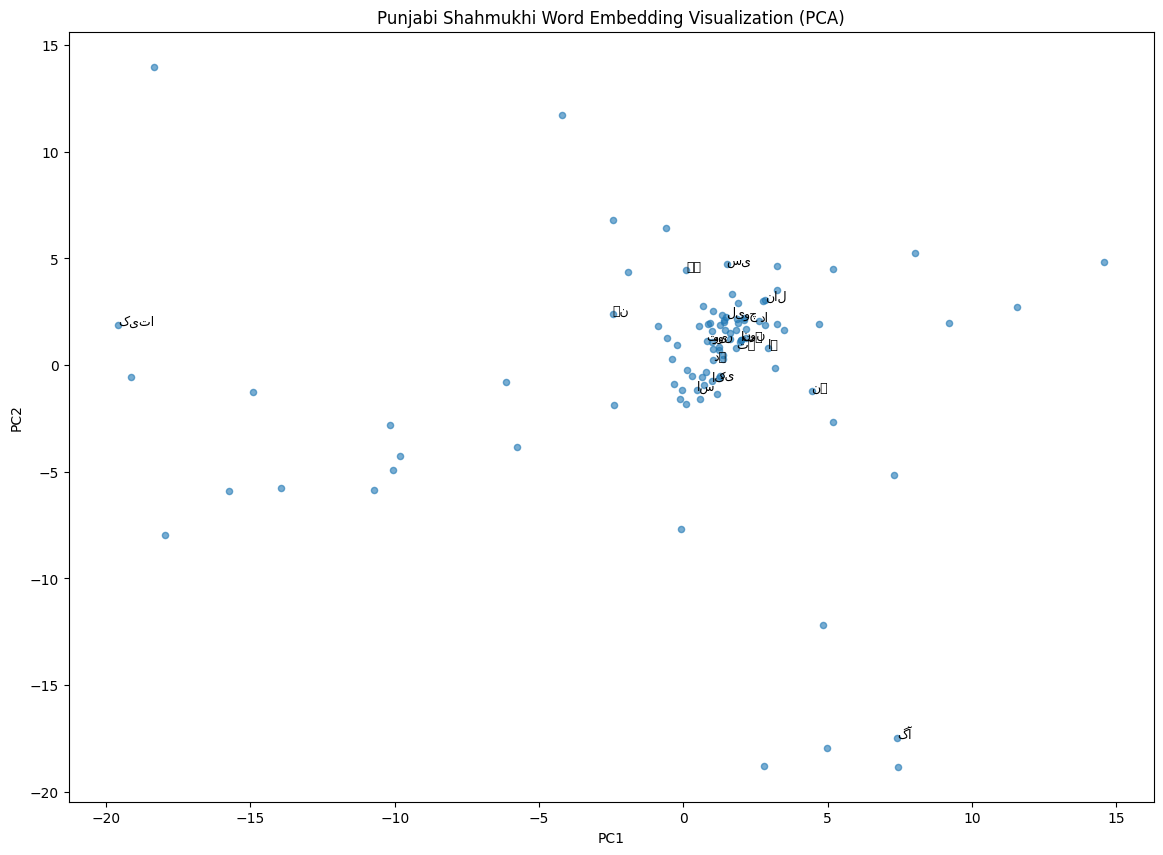

In [68]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

words = punjabi_shahmukhi_model.wv.index_to_key[:100]
vectors = punjabi_shahmukhi_model.wv[words]

pca = PCA(n_components=2)
result = pca.fit_transform(vectors)

plt.figure(figsize=(14, 10))
plt.scatter(result[:, 0], result[:, 1], alpha=0.6, s=20)

for i, word in enumerate(words[:20]):   # label only first 20
    plt.annotate(word, (result[i, 0], result[i, 1]), fontsize=9)

plt.title("Punjabi Shahmukhi Word Embedding Visualization (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.savefig("punjabi_shahmukhi_embedding_pca.png", dpi=300, bbox_inches="tight")
plt.show()

Save final important files

In [69]:
important_files = [
    "urdu_corpus_normalized.txt",
    "punjabi_shahmukhi_corpus_cleaned2.txt",
    "urdu_word2vec.model",
    "punjabi_shahmukhi_word2vec_cleaned.model",
    "urdu_embedding_pca.png",
    "punjabi_shahmukhi_embedding_pca.png"
]

for f in important_files:
    print(f)

urdu_corpus_normalized.txt
punjabi_shahmukhi_corpus_cleaned2.txt
urdu_word2vec.model
punjabi_shahmukhi_word2vec_cleaned.model
urdu_embedding_pca.png
punjabi_shahmukhi_embedding_pca.png


In [70]:
import re

input_file = "punjabi_shahmukhi_corpus.txt"
output_file = "punjabi_shahmukhi_corpus_final.txt"

NOISE_WORDS = [
    "سرےنی", "ہوالے", "وکیپیڈیا", "پربندھک", "مکھ", "سپھا"
]

def clean_shahmukhi_text(text):
    text = text.replace("\u200c", " ")
    text = text.replace("\ufeff", " ")
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[\u064B-\u065F]", "", text)   # remove diacritics
    text = re.sub(r"[^\u0600-\u06FF\s]", " ", text)

    for w in NOISE_WORDS:
        text = re.sub(rf"\b{re.escape(w)}\b", " ", text)

    text = re.sub(r"\s+", " ", text).strip()
    return text

with open(input_file, "r", encoding="utf-8") as infile, open(output_file, "w", encoding="utf-8") as outfile:
    for line in infile:
        cleaned = clean_shahmukhi_text(line)
        if cleaned and len(cleaned.split()) >= 3:
            outfile.write(cleaned + "\n")

print("Saved:", output_file)

Saved: punjabi_shahmukhi_corpus_final.txt


In [71]:
!head -n 20 punjabi_shahmukhi_corpus_final.txt

مںبی مںبی تک بںبی بھارت دے مہاںراسٹر سوبے دی راجدھانی ہے اتے اہ بھارت دا دوسرا وڈا مہاںنگر ہے بھارت دے پچھمی تٹ اتے ستھت ہے اس دی جنسںکھآ لگبھگ کروڑ لکھ ہے اہ بھارت دا سبھ توں جآدا آبادی والا سہر ہے اس دا گٹھن لاوا نرمت ست چھوٹے چھوٹے دیپاں دآرا ہواآ ہے اتے اہ پلاں دآرا پرمکھ دھرتی کھںڈ دے نال جڑآ ہواآ ہے مںبی بںدرگاہ بھارت دا سبھ توں وڈی سمںدری بںدرگاہ ہے مںبی دا سمںدری کنارا کٹآ پھٹآ ہے جسدے کارن اس دا بںدرگاہ سبھاوک اتے سرکھات ہے یورپ امریکا اپھریکا آد پچھمی دےساں نال جلمارگ جاں وایو مارگ راہیں آان والے جہاج اتے یاتری سبھ توں پہلاں مںبی ہی آاںدے رہے ہن اس لی مںبی نوں بھارت دا پروےسدوار کہا جاںدا ہے اںکڑے مںبی بھارت دا وڈا کاروباری کےںدر ہے جسدی بھارت دے سکل گھرےلو اتپاد وچ دی بھاگیداری ہے اہ پورے بھارت دے ادیوگک اتپاد دا سمںدری وپار دا اتے بھارتی ارتھ ووستھا دے پوںجی لےن دےن دا ہسےدار ہے مںبی سںسار دے سرو اچ دس کاروباری کےںدراں وچوں اک ہے بھارت دے سارے بےںک اتے کاروباری دپھتراں دے دپھتر اتے کی مہتوپورن آرتھک سںستھان جوےں بھارتی رجرو بےںک بںبی سٹاک ےکسچےںج نےسنل سٹآک ےکسچےںج اتے انےک

In [72]:
from collections import Counter

freq = Counter()

with open("punjabi_shahmukhi_corpus_final.txt", "r", encoding="utf-8") as f:
    for line in f:
        freq.update(line.split())

print(freq.most_common(50))

[('وچ', 637948), ('دے', 548335), ('ہے', 485249), ('اتے', 468611), ('دی', 381267), ('نوں', 284114), ('دا', 278490), ('اک', 241445), ('سی', 228337), ('اس', 208434), ('اہ', 196089), ('توں', 195840), ('نے', 169216), ('ہن', 159958), ('لی', 148478), ('نال', 147715), ('تے', 145091), ('کیتا', 108778), ('وی', 98598), ('گآ', 95658), ('ک', 83159), ('کیتی', 78955), ('جو', 72911), ('جاںدا', 61406), ('دیآں', 60575), ('کرن', 60113), ('اسنے', 56807), ('بھارتی', 56423), ('دآرا', 51803), ('سںگھ', 49785), ('سن', 48726), ('جس', 48444), ('بااد', 48089), ('آپنے', 47967), ('بھارت', 47644), ('کے', 47315), ('گی', 46781), ('جنم', 46774), ('جاں', 45593), ('وجوں', 43685), ('نہیں', 40691), ('ہو', 40668), ('تور', 40049), ('ہواآ', 39895), ('ہی', 39591), ('لوک', 38848), ('سال', 37354), ('انہاں', 37204), ('پھلم', 37154), ('تک', 36595)]


In [73]:
from gensim.models import Word2Vec
from gensim.models.word2vec import LineSentence

sentences = LineSentence("punjabi_shahmukhi_corpus_final.txt")

punjabi_shahmukhi_model = Word2Vec(
    sentences=sentences,
    vector_size=200,
    window=5,
    min_count=2,
    workers=4,
    sg=0
)

punjabi_shahmukhi_model.save("punjabi_shahmukhi_word2vec_final.model")
print("Saved punjabi_shahmukhi_word2vec_final.model")
print("Vocabulary size:", len(punjabi_shahmukhi_model.wv))

Saved punjabi_shahmukhi_word2vec_final.model
Vocabulary size: 160593


In [74]:
punjabi_queries = ["پاکستان", "لاہور", "پنجاب", "پنجابی"]

for word in punjabi_queries:
    if word in punjabi_shahmukhi_model.wv:
        print(f"\nPunjabi Shahmukhi nearest neighbors for: {word}")
        print(punjabi_shahmukhi_model.wv.most_similar(word, topn=10))
    else:
        print(f"{word} not found in Punjabi Shahmukhi vocabulary")


Punjabi Shahmukhi nearest neighbors for: پاکستان
[('اپھگانستان', 0.6976237893104553), ('بںگلادےس', 0.6930825710296631), ('کراچی', 0.634261429309845), ('پاکستانی', 0.6182680130004883), ('بلوچستان', 0.6018438935279846), ('اسلاماباد', 0.601272463798523), ('کھےبر', 0.5912110209465027), ('سںدھ', 0.5845648050308228), ('لاہور', 0.5793077349662781), ('راولپںڈی', 0.5694912075996399)]

Punjabi Shahmukhi nearest neighbors for: لاہور
[('لہور', 0.7704333662986755), ('کراچی', 0.7407424449920654), ('راولپںڈی', 0.7273037433624268), ('ملتان', 0.7105137705802917), ('اںمرتسر', 0.6843017339706421), ('گجراںوالا', 0.6664878129959106), ('پساور', 0.6354209184646606), ('اسلاماباد', 0.628426730632782), ('سآلکوٹ', 0.6276400089263916), ('پھےسلاباد', 0.6224473714828491)]
پنجاب not found in Punjabi Shahmukhi vocabulary
پنجابی not found in Punjabi Shahmukhi vocabulary


/tmp/ipykernel_240/3373538883.py:19: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.savefig("punjabi_shahmukhi_embedding_pca_final.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_240/3373538883.py:19: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.savefig("punjabi_shahmukhi_embedding_pca_final.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_240/3373538883.py:19: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.savefig("punjabi_shahmukhi_embedding_pca_final.png", dpi=300, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Arabic natively.
  fig.canvas.print_figure(bytes_io,

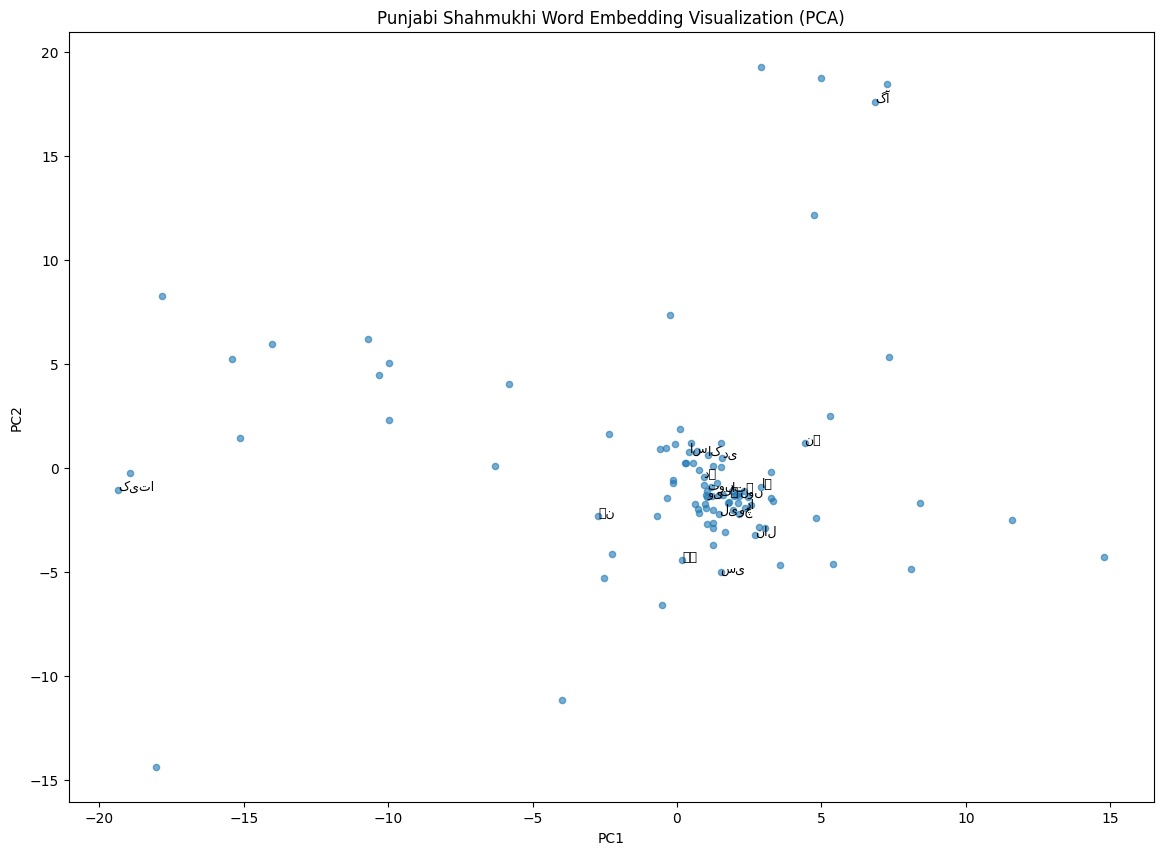

In [75]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

words = punjabi_shahmukhi_model.wv.index_to_key[:100]
vectors = punjabi_shahmukhi_model.wv[words]

pca = PCA(n_components=2)
result = pca.fit_transform(vectors)

plt.figure(figsize=(14, 10))
plt.scatter(result[:, 0], result[:, 1], alpha=0.6, s=20)

for i, word in enumerate(words[:20]):
    plt.annotate(word, (result[i, 0], result[i, 1]), fontsize=9)

plt.title("Punjabi Shahmukhi Word Embedding Visualization (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.savefig("punjabi_shahmukhi_embedding_pca_final.png", dpi=300, bbox_inches="tight")
plt.show()

In [76]:
for w in ["پنجاب", "پںجاب", "پنجابی", "پںجابی"]:
    print(w, w in punjabi_shahmukhi_model.wv)

پنجاب False
پںجاب True
پنجابی False
پںجابی True


In [77]:
punjabi_queries = ["پاکستان", "لاہور", "پںجاب", "پںجابی"]

for word in punjabi_queries:
    if word in punjabi_shahmukhi_model.wv:
        print(f"\nPunjabi Shahmukhi nearest neighbors for: {word}")
        print(punjabi_shahmukhi_model.wv.most_similar(word, topn=10))
    else:
        print(f"{word} not found in Punjabi Shahmukhi vocabulary")


Punjabi Shahmukhi nearest neighbors for: پاکستان
[('اپھگانستان', 0.6976237893104553), ('بںگلادےس', 0.6930825710296631), ('کراچی', 0.634261429309845), ('پاکستانی', 0.6182680130004883), ('بلوچستان', 0.6018438935279846), ('اسلاماباد', 0.601272463798523), ('کھےبر', 0.5912110209465027), ('سںدھ', 0.5845648050308228), ('لاہور', 0.5793077349662781), ('راولپںڈی', 0.5694912075996399)]

Punjabi Shahmukhi nearest neighbors for: لاہور
[('لہور', 0.7704333662986755), ('کراچی', 0.7407424449920654), ('راولپںڈی', 0.7273037433624268), ('ملتان', 0.7105137705802917), ('اںمرتسر', 0.6843017339706421), ('گجراںوالا', 0.6664878129959106), ('پساور', 0.6354209184646606), ('اسلاماباد', 0.628426730632782), ('سآلکوٹ', 0.6276400089263916), ('پھےسلاباد', 0.6224473714828491)]

Punjabi Shahmukhi nearest neighbors for: پںجاب
[('لدھآنا', 0.5887476801872253), ('جلںدھر', 0.5810167193412781), ('کلاں', 0.5682204961776733), ('اںمرتسر', 0.5650447010993958), ('گرداسپر', 0.5620750188827515), ('مالوے', 0.5614927411079407), ('سںگر

In [78]:
matches = [w for w in punjabi_shahmukhi_model.wv.index_to_key if "پنج" in w or "پںج" in w]
print(matches[:50])

['پںجابی', 'پںجاب', 'پںج', 'پںجابیآں', 'پںجویں', 'پںجوےں', 'پںجواں', 'پںجاہ', 'پںجابیات', 'پںجاں', 'پںجر', 'پںجرے', 'پںجے', 'پںجا', 'پںجیری', 'پنجوڑ', 'پںجابن', 'پنجی', 'پںجرا', 'پںجور', 'پںجہین', 'پںجال', 'پںجالی', 'پںجی', 'پںجوی', 'پںجوے', 'پںجابناں', 'پںجو', 'پںجاباں', 'پںجھی', 'پںجآں', 'سپںج', 'پںجگرایں', 'پںجابیآ', 'پںجیم', 'پںجوا', 'پںجےباں', 'پںجاہوآں', 'پںجم', 'پںجنیآں', 'پںجنی', 'پںجراں', 'پںجبی', 'پںجابجلںدھر', 'پںجابگرداسپر', 'پںجن', 'پںجسیر', 'پںجوڑ', 'پںجند', 'پںجاببٹھںڈا']


1️⃣ Word Similarity Evaluation (Intrinsic Evaluation)

In [81]:
from gensim.models import Word2Vec

model = Word2Vec.load("punjabi_shahmukhi_word2vec_final.model")

print("Model loaded successfully")
print("Vocabulary size:", len(model.wv))

Model loaded successfully
Vocabulary size: 160593


Define evaluation word pairs

In [82]:
word_pairs = [
    ("لاہور","کراچی"),
    ("پاکستان","افغانستان"),
    ("پںجاب","پںجابی"),
    ("کراچی","ملتان"),
    ("پاکستان","بلوچستان")
]

compute cosine similarity

In [83]:
from sklearn.metrics.pairwise import cosine_similarity

for w1, w2 in word_pairs:
    if w1 in model.wv and w2 in model.wv:
        sim = cosine_similarity(
            model.wv[w1].reshape(1,-1),
            model.wv[w2].reshape(1,-1)
        )[0][0]
        print(f"{w1} - {w2} : {sim:.3f}")
    else:
        print(f"{w1} or {w2} not found in vocabulary")

لاہور - کراچی : 0.741
پاکستان or افغانستان not found in vocabulary
پںجاب - پںجابی : 0.538
کراچی - ملتان : 0.575
پاکستان - بلوچستان : 0.602


In [84]:
!pip install scikit-learn matplotlib

t-SNE Visualization

/tmp/ipykernel_240/2195522268.py:22: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.savefig("punjabi_shahmukhi_tsne.png")
/tmp/ipykernel_240/2195522268.py:22: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.savefig("punjabi_shahmukhi_tsne.png")
/tmp/ipykernel_240/2195522268.py:22: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.savefig("punjabi_shahmukhi_tsne.png")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Arabic natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) mis

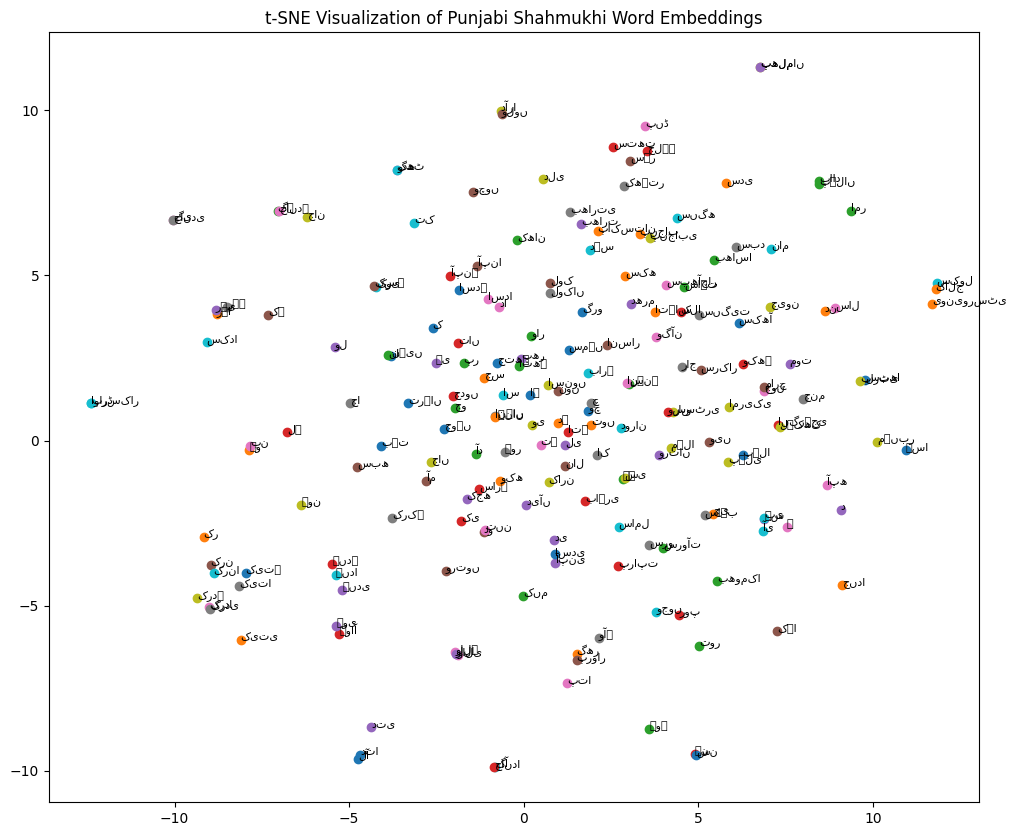

In [85]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# take first 200 words
words = list(model.wv.index_to_key[:200])

# convert vectors to numpy array
vectors = np.array([model.wv[w] for w in words])

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
coords = tsne.fit_transform(vectors)

plt.figure(figsize=(12,10))

for i, word in enumerate(words):
    x, y = coords[i]
    plt.scatter(x, y)
    plt.annotate(word, (x, y), fontsize=8)

plt.title("t-SNE Visualization of Punjabi Shahmukhi Word Embeddings")
plt.savefig("punjabi_shahmukhi_tsne.png")
plt.show()